In [1]:
import numpy as np
from numpy import linalg as la
from matplotlib.pyplot import figure,show
from numpy import sin,cos,radians
from scipy import interpolate as ip

# LINALG

## Question 7.1

In [2]:
A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
print(f"The determinant of the matrix A is {la.det(A)}")
print('--'*30)

B = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
b = np.array([2,2,1])
sol = la.solve(B,b)

print(f"The solution of the system is [x, y, z]={list(sol)}")
print('--'*30)

print(f"A =\n {A}\n")
print(f"A_transposed =\n {A.T}\n")
print(f"A_inverse =\n {la.inv(A)}\n")

if all(A.T[i][n] == la.inv(A)[i][n] for i in range(len(A.T)) for n in range(len(A.T[i]))):
    state = ' '
else:
    state = ' not'

print(f"A_inverse is{state} equal to A_transposed, thus A is{state} diagonal.")
print('--'*30)

evals,evecs = la.eig(A)
print("The eigenvectors and eigenvalues of the system are:")
for eVal,eVec in zip(evals,evecs):
    print(f"Vector: {eVec}\tValue: {eVal}")

The determinant of the matrix A is 1.0
------------------------------------------------------------
The solution of the system is [x, y, z]=[np.float64(38.0), np.float64(-3.0), np.float64(-10.0)]
------------------------------------------------------------
A =
 [[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]

A_transposed =
 [[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]

A_inverse =
 [[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]

A_inverse is not equal to A_transposed, thus A is not diagonal.
------------------------------------------------------------
The eigenvectors and eigenvalues of the system are:
Vector: [ 1.         -0.05055961  0.94256676]	Value: 1.0
Vector: [ 0.         -0.78318743 -0.08518794]	Value: -4.7912878474779195
Vector: [ 0.          0.6197267  -0.32297201]	Value: -0.20871215252207997


## Question 7.3

In [3]:
alpha = 180-123
beta = 90-27.4
gamma = 192.25

def Ex(angle):
    angle = radians(angle)
    return np.array([1,0,0,0,cos(angle),sin(angle),0,-sin(angle),cos(angle)]).reshape(3,3)
    
def Ey(angle):
    angle = radians(angle)
    return np.array([cos(angle),0,-sin(angle),0,1,0,sin(angle),0,cos(angle)]).reshape(3,3)

def Ez(angle):
    angle = radians(angle)
    return np.array([cos(angle),sin(angle),0,-sin(angle),cos(angle),0,0,0,1]).reshape(3,3)

E = Ez(alpha)@Ey(beta)@Ez(gamma)
print(E,'\n',) # The matrix is the required one

print('--'*30)
print(f"E_transposed =\n {E.T}\n")
print(f"E_inverse =\n {la.inv(E)}\n")

state = []

if np.allclose(E.T,la.inv(E)):
    state.append('') 
    isrot = True
else:
    print(f"E_inverse is not equal to E_transposed, so E is not a rotation matrix.\n")
    isrot = False

if isrot and la.det(E) - 1 > 10e-6: # python memory catche
    isrot = False
    state.append('but')
else:
    state.append('and')

if isrot:
    print(f"E_inverse is{state[0]} equal to E_transposed {state[1]} det(E) is{state[0]} equal to 1, thus E is{state[0]} a rotation matrix.\n")

print('--'*30)
evals, evecs = la.eig(E)
print(f"The only real eigenvalue of the matrix E is {round(evals[evals.real == evals][0].real)}\n")

print('--'*30)
RA = 192.25
DEC = 27.4
v = [cos(np.radians(RA))*cos(np.radians(DEC)),cos(np.radians(DEC))*sin(np.radians(RA)),sin(np.radians(DEC))]
v = np.array(v)
print(f"The vector is v = {v}")
v_len = np.sqrt(sum(v**2))
print(f"The norm of v is {v_len:.4f}\n")

print('--'*30)
print(f"If we rotate v by e: \n\tE*v (matrix multiplication) is: {list(map(round,E@v))}")

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]] 

------------------------------------------------------------
E_transposed =
 [[-0.06698874  0.49272847 -0.86760081]
 [-0.87275577 -0.45034696 -0.1883746 ]
 [-0.48353891  0.74458463  0.46019978]]

E_inverse =
 [[-0.06698874  0.49272847 -0.86760081]
 [-0.87275577 -0.45034696 -0.1883746 ]
 [-0.48353891  0.74458463  0.46019978]]

E_inverse is equal to E_transposed and det(E) is equal to 1, thus E is a rotation matrix.

------------------------------------------------------------
The only real eigenvalue of the matrix E is 1

------------------------------------------------------------
The vector is v = [-0.86760081 -0.1883746   0.46019978]
The norm of v is 1.0000

------------------------------------------------------------
If we rotate v by e: 
	E*v (matrix multiplication) is: [0, 0, 1]


------
# INTERPOL, INTEGRAL

## Question 7.5

The coefficients are [-2.17117476e-04  1.09925609e-02 -2.39059756e-01  2.91867714e+00
 -2.19331359e+01  1.04544074e+02 -3.13633556e+02  5.65812237e+02
 -5.51003146e+02  2.18582332e+02]
Coefficient at order 9 is very small
The polinomial is: y = (0.01)*x^8 + (-0.24)*x^7 + (2.92)*x^6 + (-21.93)*x^5 + (104.54)*x^4 + (-313.63)*x^3 + (565.81)*x^2 + (-551.00)*x^1 + (218.58)*x^0


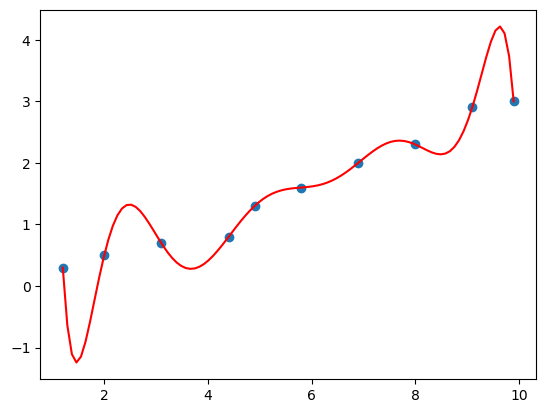

In [4]:
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n_deg = x.size-1
p = []
for i in range(len(x)):
    for n in range(x.size):
        p.append(x[i]**(n_deg-n))

p = np.array(p).reshape(10,10)
# y = p(x) = A*c*x (A is an nxn matrix, c: coefficient vector)

c = la.solve(p,y)
print(f"The coefficients are {c}")

equ = ""
for i in range(x.size):
    if abs(round(c[i],2)) != 0:
        equ += f"({c[i]:.2f})*x^{n_deg-i}"
        if i != x.size-1:
            equ += " + "
    else:
        print(f"Coefficient at order {n_deg-i} is very small")
print(f"The polinomial is: y = {equ}")

domain = np.linspace(np.min(x),np.max(x),100)
plot_data = []

for i in range(domain.size):
    value = sum(c[n]*domain[i]**(n_deg-n) for n in range(x.size))
    plot_data.append(value)

fig = figure()
ax = fig.add_subplot()
ax.scatter(x,y)
ax.plot(domain,plot_data,color='r',label = f"y = {equ}")
show()

## Question 7.6

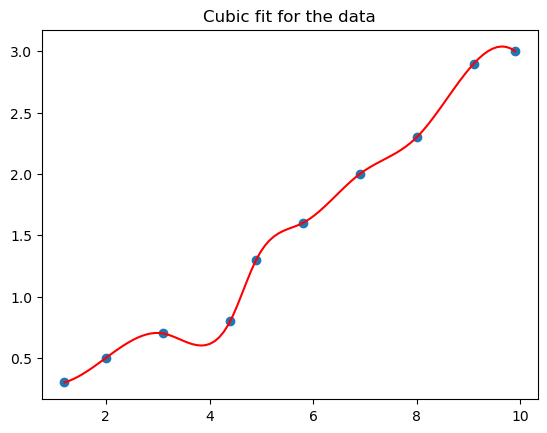

Input a value within the range 1.2 and 9.9 (inclusive):  6


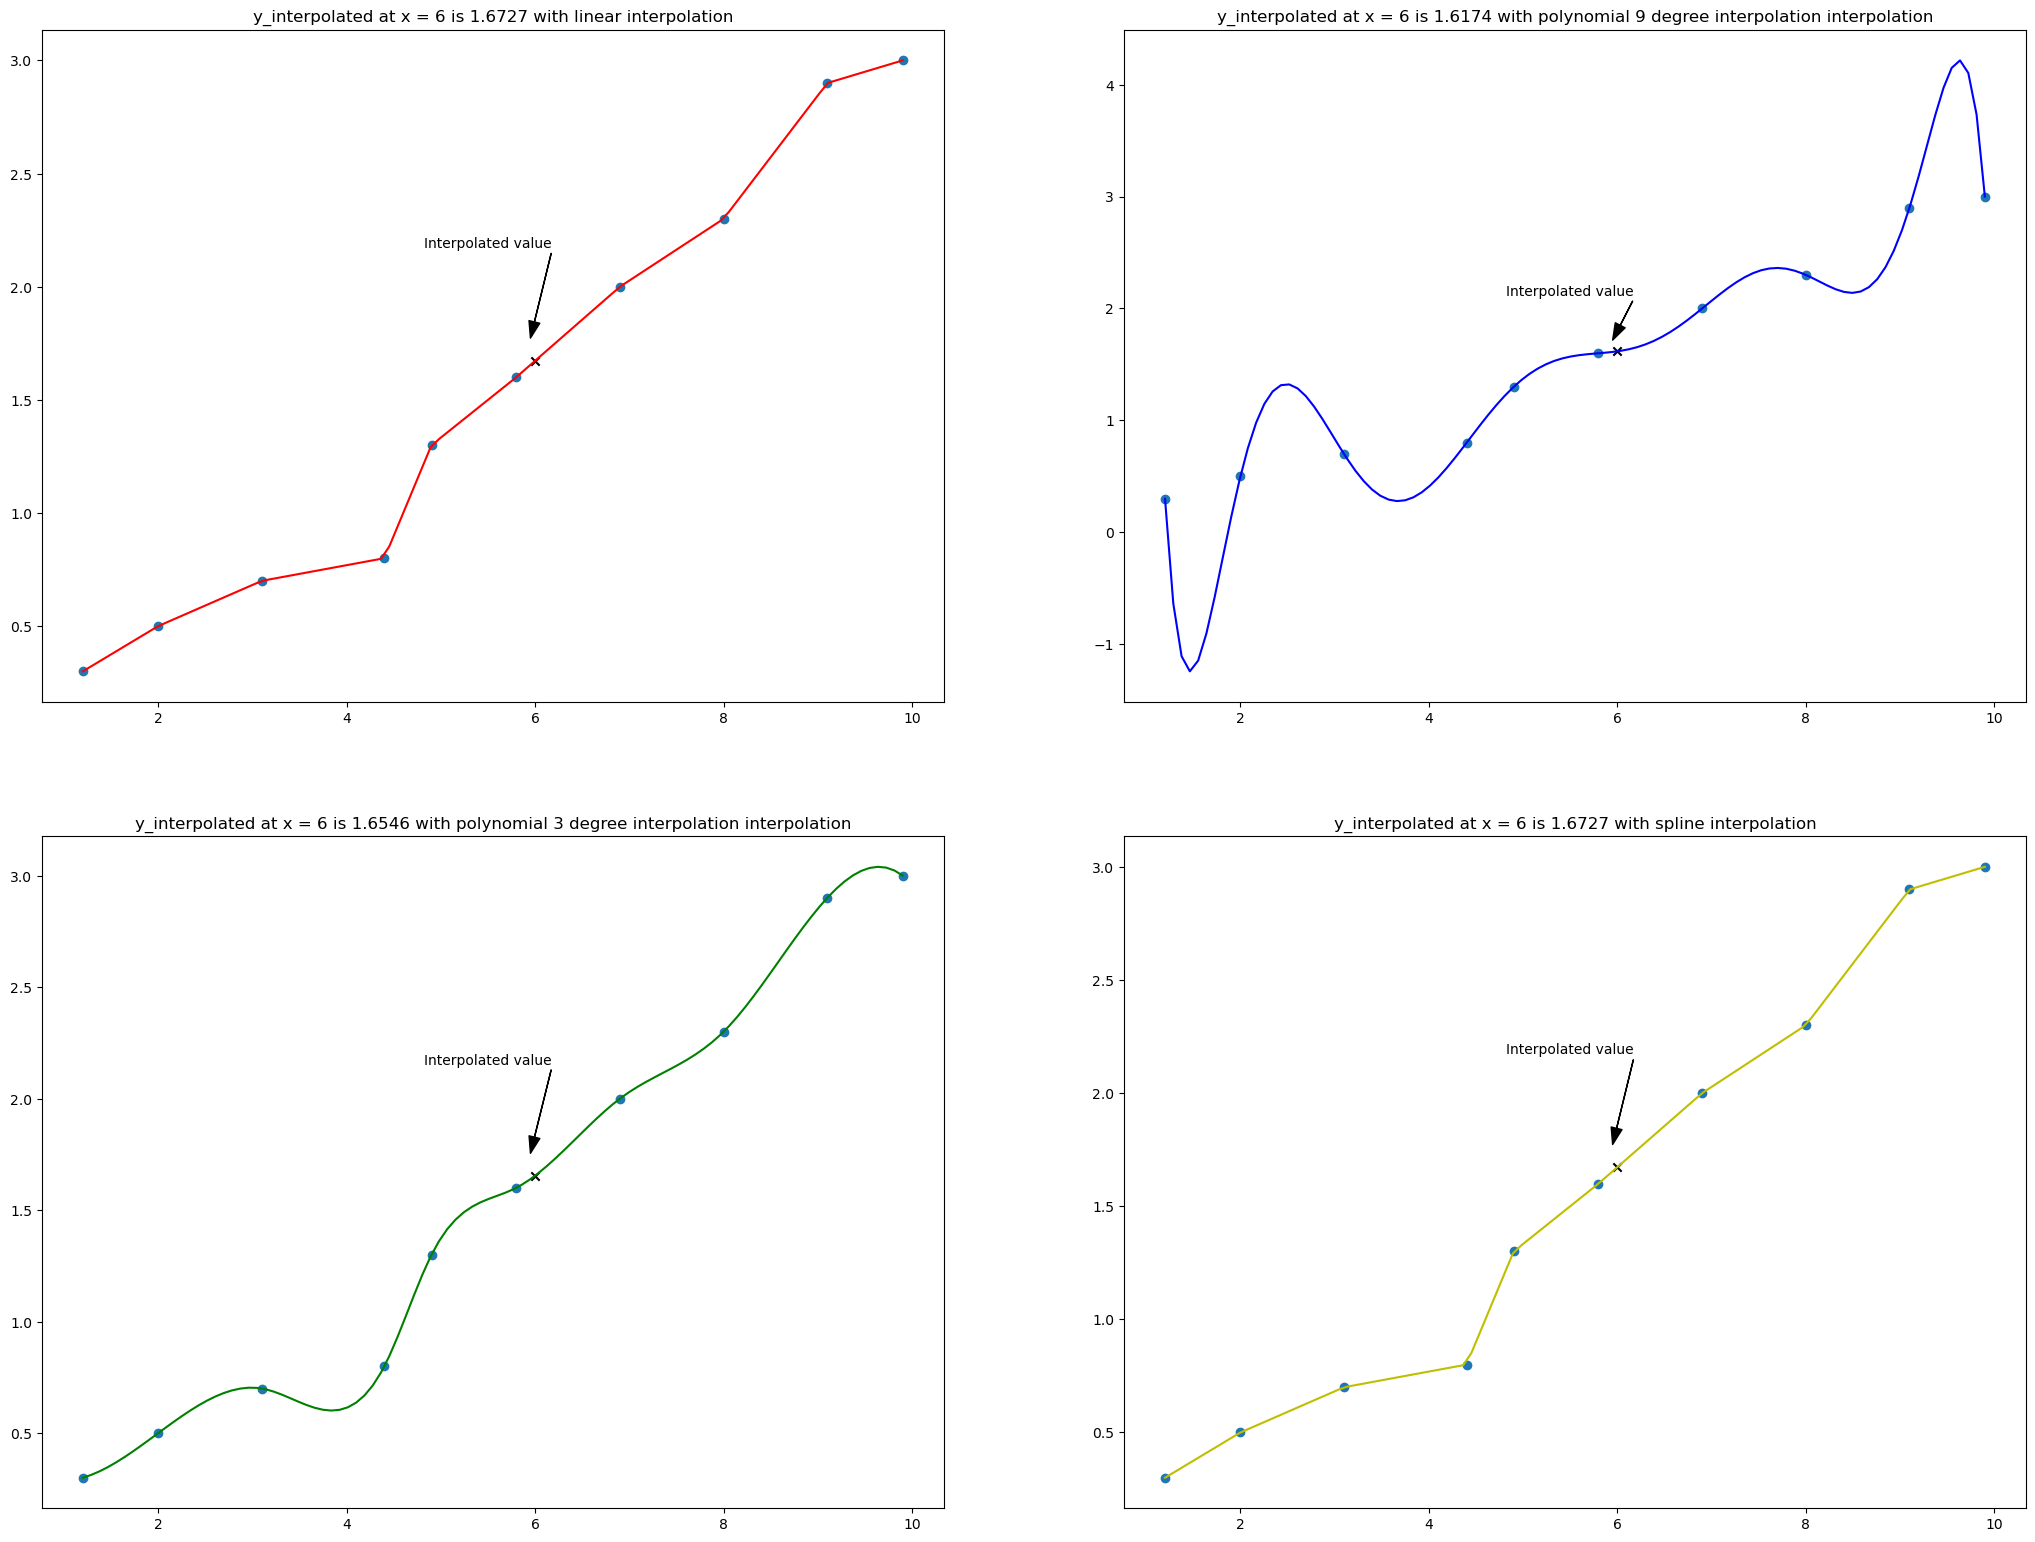

In [5]:
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

cubic_fit = ip.interp1d(x,y,kind='cubic')

domain = np.linspace(np.min(x),np.max(x),100)
plot_data = cubic_fit(domain)

fig = figure()
ax = fig.add_subplot()
ax.scatter(x,y)
ax.plot(domain,plot_data,color='r',label = f"y = {equ}")
ax.set_title('Cubic fit for the data')
show()
# THOUGHT SHARE: FIT IN QUESTION 7.5 IS OVERFITTING

class Interpolation:
    def __init__(self,x,y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)

    def linear(self):
        return ip.interp1d(self.x,self.y,kind='linear')

    def polynomial(self,degree = None):
        
        if degree == 2:
            return ip.interp1d(self.x,self.y,kind='quadratic')
        elif degree == 3:
            return ip.interp1d(self.x,self.y,kind='cubic')
        else:
            return ip.lagrange(self.x,self.y)

    def spline(self):
        return ip.interp1d(self.x,self.y,kind='slinear')

    def value(self,X,method='linear',degree = None):
        if method == 'linear':
            try:
                return self.linear()(X)
            except:
                return "Error"
                
        elif method == 'spline':
            try:
                return self.spline()(X)
            except:
                return "Error"
                
        elif method == 'polynomial':
            try:
                return self.polynomial(degree=degree)(X)
            except:
                return "Error"
                
        else:
            return "TypeError the requested method is not possible with the function"


#########################################
previous = Interpolation(x,y)
fig = figure()
w, h = fig.get_size_inches()
fig.set_size_inches(w * 4, h * 4)

X = eval(input(f"Input a value within the range {np.min(x)} and {np.max(x)} (inclusive): "))


methods = ['linear','polynomial','polynomial','spline']
degs = [None,x.size-1,3,None]
colors = ['r','b','g','y']

for i in range(len(methods)):
    ax = fig.add_subplot(2,2,i+1)
    ax.scatter(x,y)

    m = methods[i]
    deg = degs[i]
    
    Y = previous.value(X,method=m,degree = deg)

    if m == 'linear':
        plot_data = previous.linear()(domain)
        ax.set_title(f"y_interpolated at x = {X} is {Y:.4f} with linear interpolation")
    elif m == 'polynomial':
        plot_data = previous.polynomial(degree=deg)(domain)
        ax.set_title(f"y_interpolated at x = {X} is {Y:.4f} with polynomial {deg} degree interpolation interpolation")
    elif m == 'spline':
        plot_data = previous.spline()(domain)
        ax.set_title(f"y_interpolated at x = {X} is {Y:.4f} with spline interpolation")

    ax.plot(domain,plot_data,color=colors[i])

    ax.scatter(X,Y,marker='x',color = 'black')
    arrow = {'color':'black','width':0.1,'headwidth':8}
    ax.annotate(xy = (X-0.05,Y+0.1),xytext=(X-0.5,Y+0.5),text='Interpolated value',horizontalalignment  = 'center',arrowprops=arrow)

show()

## Question 7.7

In [8]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

row_y = 0.2 # Row position is y value
col_x = 0.7  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")

[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.2,0.7 => x, y=0.70.2 is 3.458000


------
# MODEL FITTING

## Question 7.10

In [9]:
import scipy.optimize as opt

------
# GIT

## Question 7.14